In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
files = Path("out_shap").glob("shap_global_*.csv")

rows = {}
for f in files:
    name = f.stem.replace("shap_global_", "")
    df = pd.read_csv(f)
    rows[name] = pd.Series(df["mean_abs_shap"].values, index=df["feature"])

importance_df = pd.DataFrame(rows).T
importance_df = importance_df.fillna(0.0)
print(importance_df)
# optional: normalize each model row so they’re comparable
importance_norm = importance_df.div(importance_df.sum(axis=1), axis=0)
print(importance_norm)

feature         daily_avg_weight_lag_1d  daily_avg_weight_lag_1w  \
CatBoost                       0.000000                 0.000000   
LigthGBM_model                 0.381468                 0.775682   
XGB_model                      0.000000                 0.000000   

feature         daily_avg_weight_lag_2d  daily_weight_lag_1d  \
CatBoost                        0.00000             0.000000   
LigthGBM_model                  0.16888             0.784886   
XGB_model                       0.00000             0.000000   

feature         daily_weight_lag_1w  daily_weight_lag_2d   dow_cos   dow_sin  \
CatBoost                   0.000000             0.000000  0.000000  0.000000   
LigthGBM_model             0.396633             0.323265  0.895694  0.664933   
XGB_model                  0.000000             0.000000  0.000000  0.000000   

feature         dow_target  generation_fc  ...  ramp_1h_t0  ramp_6h_t0  \
CatBoost          5.836825       0.000000  ...    0.176801    0.022140   
L

In [3]:
def plot_heatmap(df, title, top_k=25):

    # pick most important features overall
    top_features = df.mean(axis=0).sort_values(ascending=False).head(top_k).index
    
    plot_df = df[top_features].T  # features = rows, models = columns

    fig, ax = plt.subplots(figsize=(0.8 * plot_df.shape[1] + 3,
                                    0.4 * plot_df.shape[0] + 3))

    im = ax.imshow(plot_df.values, aspect="auto")

    ax.set_title(title)

    # X axis = models
    ax.set_xticks(np.arange(plot_df.shape[1]))
    ax.set_xticklabels(plot_df.columns, rotation=45, ha="left")

    # Move model names to the TOP
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # Y axis = features
    ax.set_yticks(np.arange(plot_df.shape[0]))
    ax.set_yticklabels(plot_df.index)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("mean(|SHAP|)")

    plt.tight_layout()
    plt.show()

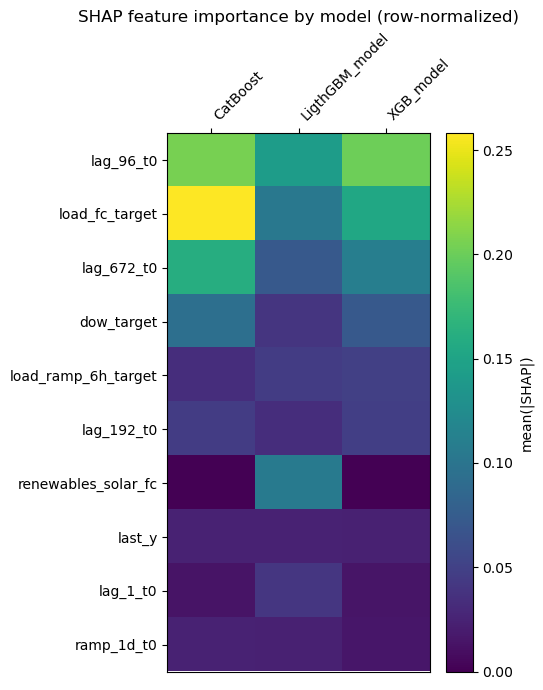

In [4]:
plot_heatmap(importance_norm, "SHAP feature importance by model (row-normalized)", top_k=10)